In [1]:
import pandas as pd
from difflib import SequenceMatcher
import os
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
dataset = pd.read_csv("dataset_with_incorrect_answers.csv")

In [3]:
def compare_outputs(row):

    output = str(row["Output"])
    incorrect_output = str(row["IncorrectOutput"])
    
    similarity_ratio = SequenceMatcher(None, output, incorrect_output).ratio()
    return similarity_ratio

def find_identical_rows(dataset):

    identical_rows = dataset[dataset["Output"] == dataset["IncorrectOutput"]]
    identical_rows = identical_rows.reset_index(drop=True)
    
    if not identical_rows.empty:
        print("\nRiadky, kde Output a IncorrectOutput sú rovnaké:")
        print(identical_rows[["Instruction", "Input", "Output", "Category", "Subcategory", "IncorrectOutput"]])
    else:
        print("\nNeboli nájdené žiadne riadky, kde Output a IncorrectOutput sú rovnaké.")

In [4]:
dataset["Similarity"] = dataset.apply(compare_outputs, axis=1)

find_identical_rows(dataset)

if os.path.exists("dataset_with_similarity.csv"):
    os.remove("dataset_with_similarity.csv")
    print("Starý súbor 'dataset_with_similarity.csv' bol odstránený.")
output_file = "dataset_with_similarity.csv"
dataset.to_csv(output_file, index=False)
print(f"Dataset s podobnosťou bol uložený do súboru: {output_file}")


Riadky, kde Output a IncorrectOutput sú rovnaké:
                                            Instruction  \
0     Write a function to calculate the total number...   
1     Write a Python program to generate a Fibonacci...   
2     Design a Python function to calculate the area...   
3     Develop an algorithm in Python to find the dep...   
4     Write a function to sort a list of tuples usin...   
...                                                 ...   
2415  Generate a Python program that reads a line fr...   
2416  Debug the following python code to make the co...   
2417  Edit the following Python code to re-rank the ...   
2418  Generate a python function that takes a list o...   
2419  Write a Python program to count words in a sen...   

                                                  Input  \
0                                                   NaN   
1                               Number of elements = 10   
2                                                   NaN   
3    

In [5]:
# Počet otázok, kde Similarity == 1
similar_questions_count = dataset[dataset["Similarity"] == 1].shape[0]

print(f"Počet otázok so Similarity == 1: {similar_questions_count}")

Počet otázok so Similarity == 1: 2420


In [6]:
similar_rows = dataset[dataset["Similarity"] == 1]
# Počet jedinečných podskupín (Subcategory)
unique_subcategories_count = similar_rows["Subcategory"].nunique()

print(f"Počet jedinečných podskupín so Similarity == 1: {unique_subcategories_count}")

Počet jedinečných podskupín so Similarity == 1: 56


In [7]:
unique_subcategories = similar_rows["Subcategory"].unique()
print("Jedinečné podskupiny so Similarity == 1:")
print(unique_subcategories)

Jedinečné podskupiny so Similarity == 1:
['calculate' 'fibonacci' 'tree' 'sort' 'list' 'sum' 'number' 'lambda'
 'variable' 'mean' 'parameter' 'array' 'dictionary' 'continue' 'read'
 'for loop' 'print' 'sorting' 'while' 'linked list' 'date' 'set'
 'generator' 'decision' 'multiply' 'duplicate' 'error' 'exception'
 'histogram' 'case' 'loop' 'if' 'dataframe' 'debug' 'quick sort' 'file'
 'plot' 'matplotlib' 'prime' 'open' 'numpy' 'median' 'csv' 'analysis'
 'xml' 'try' 'visualization' 'data type' 'calculator' 'queue' 'close'
 'boolean' 'optimization' 'condition' 'stack' 'distribution']


In [8]:
data_s = pd.read_csv("dataset_with_similarity.csv")
data_c = pd.read_csv("dataset_with_incorrect_answers.csv")

In [9]:
similar_questions = data_s[data_s["Similarity"] == 1]

# Odstránenie otázok z data_c, ktoré sú v similar_questions
# Porovnáva sa na základe 'Instruction' a 'Input'
filtered_data = data_c[~data_c[["Instruction", "Input"]].apply(
    tuple, axis=1).isin(similar_questions[["Instruction", "Input"]].apply(tuple, axis=1))]

filtered_data['ID'] = range(1, len(filtered_data) + 1)

stlpce = filtered_data.columns.tolist()
stlpce = ['ID'] + [stlpec for stlpec in stlpce if stlpec != 'ID']
filtered_data = filtered_data[stlpce]

if os.path.exists("final_dataset.csv"):
    os.remove("final_dataset.csv")
    print("Starý súbor 'final_dataset.csv' bol odstránený.")
output_file = "final_dataset.csv"
filtered_data.to_csv(output_file, index=False)
print(f"Upravený dataset bol uložený do súboru: {output_file}")

Starý súbor 'final_dataset.csv' bol odstránený.
Upravený dataset bol uložený do súboru: final_dataset.csv


C:\Users\firda\AppData\Local\Temp\ipykernel_39528\1703979942.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ID'] = range(1, len(filtered_data) + 1)


In [15]:
similar_questions = data_s[data_s["Similarity"] == 1]

# Odstránenie otázok z data_c, ktoré sú v similar_questions
# Porovnáva sa na základe 'Instruction' a 'Input'
filtered_data = data_c[~data_c[["Instruction", "Input"]].apply(
    tuple, axis=1).isin(similar_questions[["Instruction", "Input"]].apply(tuple, axis=1))]

# Ponechaj len tie otázky, ktoré sú v runnable_with_output
runnable_with_output = pd.read_csv("test_spustitelnosti/runnable_with_output.csv")
runnable_keys = set(runnable_with_output[["Instruction", "Input"]].apply(tuple, axis=1))
filtered_data = filtered_data[filtered_data[["Instruction", "Input"]].apply(tuple, axis=1).isin(runnable_keys)]

# Resetuj ID od 1
filtered_data['ID'] = range(1, len(filtered_data) + 1)

# Usporiadanie stĺpcov – ID musí byť prvý
stlpce = filtered_data.columns.tolist()
stlpce = ['ID'] + [stlpec for stlpec in stlpce if stlpec != 'ID']
filtered_data = filtered_data[stlpce]


if os.path.exists("final_dataset.csv"):
    os.remove("final_dataset.csv")
    print("🗑️ Starý súbor 'final_dataset.csv' bol odstránený.")

output_file = "final_dataset.csv"
filtered_data.to_csv(output_file, index=False)
print(f"✅ Upravený dataset bol uložený do súboru: {output_file}")

🗑️ Starý súbor 'final_dataset.csv' bol odstránený.
✅ Upravený dataset bol uložený do súboru: final_dataset.csv


Analýza FINAL_DATASET

In [16]:
vysledny_dataset = pd.read_csv("final_dataset.csv")

In [17]:
vysledny_dataset

,ID,Instruction,Input,Output,Category,Subcategory,IncorrectOutput
0,1,Create a function in Python which takes a list...,"[3, 4, 5]",def sum_squares(nums):\n result = 0\n fo...,Data Structures,list,define sum_squares(nums):\n result = 0\n ...
1,2,Design a function in Python that sorts a list ...,"['red', 'green', 'orange']",def sort_list_alphabetically(input_list): \n ...,Sorting,sort,def sort_list_alphabetically(input_list): \n ...
2,3,Edit the following Python code such that it wi...,"days = [""Monday"", ""Thuesday"", ""Wednesday"", ""Th...","days = ['Monday', 'Tuesday', 'Wednesday', 'Thu...",Syntax,print,"days == [""Monday"", ""Tuesday"", ""Wednesday"", ""Th..."
3,4,Write a Python program to generate a sorted li...,NaN,import random\n\n# generating a list of unique...,Data Structures,list,import random\n\n# generating a list of unique...
4,5,Create a Python program to sort a list of tupl...,"[(21, ""ABC"", 33), (9, ""XYZ"", 88), (67, ""MNO"", ...",def sort_tuple_list(tuple_list):\n sorted_t...,Sorting,sort,def sort_tuple_list(tuple_list):\n sorted_t...
...,...,...,...,...,...,...,...
2641,2642,Generate a new Python list with the squared va...,"list = [1, 2, 3, 4, 5, 6]",def squared_list(list):\n squared_list = []...,Data Structures,list,def squared_lst(list):\n squared_list = []\...
2642,2643,Write a python program that creates and prints...,"Start from 0, increment by 2 and end at 10","for number in range(0, 11, 2):\n print(number)",Syntax,print,"for number in range(0, 11, 2):\n priteger(n..."
2643,2644,Create a web scraper in Python that loads a we...,URL: https://www.example.com/\nText to extract...,import requests\nfrom bs4 import BeautifulSoup...,Data Structures,string,import requests\nfrom bs4 import BeautifulSoup...
2644,2645,Design an algorithm in Python for finding and ...,100,def find_all_primes(n): \n for num in range(2...,Mathematics,prime,def find_all_primes(n): \n for num in range(2...


In [18]:
categories = vysledny_dataset["Category"].value_counts()
categories

Category
Data Structures                       910
Syntax                                519
Mathematics                           497
Scientific Computing                  256
Sorting                               146
Branching                              91
Loops                                  86
Object-Oriented Programming            66
Algorithms and Dynamic Programming     23
Functions and Advanced Concepts        22
File Handling                          13
Testing and Debugging                  10
Data Analysis                           7
Name: count, dtype: int64

In [19]:
vysledny_dataset["Subcategory"].unique()

array(['list', 'sort', 'print', 'calculate', 'array', 'dictionary',
       'string', 'random', 'data structure', 'temperature', 'read',
       'class', 'number', 'if', 'integer', 'fibonacci', 'sum',
       'try/except', 'loop', 'volume', 'sorting', 'matrix', 'prime',
       'object', 'average', 'pandas', 'duplicate', 'median', 'set',
       'numpy', 'parameter', 'for loop', 'elif', 'lambda', 'multiply',
       'condition', 'operator', 'date', 'debug', 'stack', 'axis',
       'optimization', 'generator', 'float', 'user input', 'nested loop',
       'max', 'while', 'variable', 'calculator', 'case', 'exception',
       'mean', 'error', 'statistic', 'pi', 'try', 'decision', 'dataframe'],
      dtype=object)

In [20]:
count_subcategory = vysledny_dataset["Subcategory"].value_counts()

print("Počet otázok v jednotlivých podkategóriách:")
for subcategory, count in count_subcategory.items():
    print(f"{subcategory}: {count} otázok")

Počet otázok v jednotlivých podkategóriách:
string: 480 otázok
list: 373 otázok
print: 369 otázok
number: 222 otázok
calculate: 145 otázok
array: 138 otázok
sort: 123 otázok
if: 82 otázok
random: 80 otázok
sum: 66 otázok
integer: 53 otázok
class: 51 otázok
loop: 48 otázok
dictionary: 46 otázok
duplicate: 45 otázok
for loop: 33 otázok
set: 32 otázok
prime: 25 otázok
average: 24 otázok
sorting: 23 otázok
temperature: 20 otázok
fibonacci: 19 otázok
object: 15 otázok
read: 13 otázok
matrix: 11 otázok
date: 10 otázok
parameter: 9 otázok
data structure: 9 otázok
generator: 7 otázok
lambda: 6 otázok
multiply: 5 otázok
user input: 4 otázok
optimization: 4 otázok
while: 4 otázok
elif: 4 otázok
median: 4 otázok
debug: 3 otázok
case: 3 otázok
calculator: 3 otázok
error: 3 otázok
variable: 3 otázok
pandas: 3 otázok
max: 3 otázok
mean: 2 otázok
exception: 2 otázok
pi: 2 otázok
numpy: 2 otázok
float: 2 otázok
stack: 2 otázok
volume: 2 otázok
nested loop: 1 otázok
axis: 1 otázok
operator: 1 otázok
co

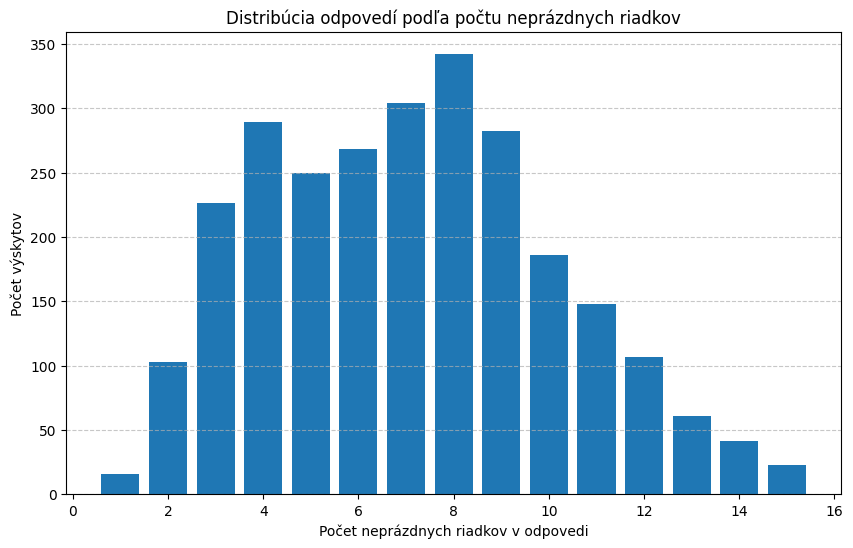

Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:
1 riadkov: 16 odpovedí
2 riadkov: 103 odpovedí
3 riadkov: 226 odpovedí
4 riadkov: 289 odpovedí
5 riadkov: 250 odpovedí
6 riadkov: 268 odpovedí
7 riadkov: 304 odpovedí
8 riadkov: 342 odpovedí
9 riadkov: 282 odpovedí
10 riadkov: 186 odpovedí
11 riadkov: 148 odpovedí
12 riadkov: 107 odpovedí
13 riadkov: 61 odpovedí
14 riadkov: 41 odpovedí
15 riadkov: 23 odpovedí


In [21]:
def count_nonempty_lines(output_text):
    if pd.isna(output_text):
        return 0
    return sum(1 for line in output_text.split('\n') if line.strip())

def create_line_count_distribution(dataset):
    # Spočítanie neprázdnych riadkov pre každú odpoveď
    line_counts = dataset['Output'].apply(count_nonempty_lines)
    distribution = Counter(line_counts)
    
    plt.figure(figsize=(10, 6))
    plt.bar(distribution.keys(), distribution.values(), width=0.8)
    plt.title("Distribúcia odpovedí podľa počtu neprázdnych riadkov")
    plt.xlabel("Počet neprázdnych riadkov v odpovedi")
    plt.ylabel("Počet výskytov")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return distribution

distribution = create_line_count_distribution(vysledny_dataset)
print("Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:")
for line_count, count in sorted(distribution.items()):
    print(f"{line_count} riadkov: {count} odpovedí")